# **1. Project Overview**

## 1.1 Business Objective

The objective of this project is building machine learning models that can accurately predict housing prices based on property characteristics.
Accurate housing price predictions can support real estate agencies, buyers, sellers, and property investors in making informed decisions.
The model help find key factors influencing house prices and improve pricing consistency in the housing market.

## 1.2 Experiment Objective

The objective of this experiment is building an ElasticNet Regression model for predicting housing prices. ElasticNet combines both L1 and L2 regularisation techniques and will be assessed to determine whether regularisation can improve predictive performance and model generalisation compared with the baseline Linear Regression model.

## 1.3 Model Hypothesis

ElasticNet Regression is expected to achieve similar or slightly better predictive performance than Linear Regression by reducing the impact of multicollinearity and controlling model complexity. Given that several selected features are related to property size and functionality, regularisation may help the model identify the most informative predictors while improving generalisation to unseen data.

# **2. Load Dataset**

In [1]:
import pandas as pd
import numpy as np

In [2]:
X_train = pd.read_csv('../data/X_train_processed.csv')
X_val = pd.read_csv('../data/X_val_processed.csv')
X_test = pd.read_csv('../data/X_test_processed.csv')

y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_val = pd.read_csv('../data/y_val.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

# **3. Model Development**

## 3.1 Import Algorithm

In [3]:
# Import ElasticNet from sklearn
from sklearn.linear_model import ElasticNet

## 3.2 Set Hyperparameters

In [14]:
# Define the range of alpha and l1_ratio for ElasticNet tuning
alpha_values = [0.001, 0.01, 0.1, 1]
l1_ratio_values = [0.25, 0.5, 0.75, 1]

## 3.3 Train Model

In [12]:
# Import RMSE, RAE, R2 score from sklearn
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import r2_score

In [15]:
# Train and Evaluate Elastic Models
results = []

for alpha in alpha_values:
    for l1_ratio in l1_ratio_values:
        regr = ElasticNet(alpha=alpha, l1_ratio = l1_ratio, random_state = 42)
        regr.fit(X_train, y_train)
        
        y_val_pred = regr.predict(X_val)
        
        results.append({
            'alpha': alpha,
            'l1_ratio': l1_ratio,
            'RMSE': rmse(y_val, y_val_pred),
            'MAE': mae(y_val, y_val_pred),
            'R2_Score': r2_score(y_val, y_val_pred)
        })
        
results_df = pd.DataFrame(results)
results_df.sort_values(by = 'RMSE')

,alpha,l1_ratio,RMSE,MAE,R2_Score
0,0.001,0.25,0.124789,0.092048,0.913403
1,0.001,0.50,0.125507,0.093656,0.912403
2,0.001,0.75,0.126612,0.095404,0.910855
3,0.001,1.00,0.127761,0.096729,0.909229
4,0.010,0.25,0.133745,0.100726,0.900527
5,0.010,0.50,0.135734,0.101427,0.897546
6,0.010,0.75,0.136972,0.101676,0.895668
7,0.010,1.00,0.138564,0.102298,0.893229
8,0.100,0.25,0.152174,0.110572,0.871226
9,0.100,0.50,0.171187,0.124995,0.837036


In [16]:
# Select the Best Model
best_regr = ElasticNet(
    alpha = 0.001,
    l1_ratio = 0.25,
    random_state = 42
)

best_regr.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.001
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.25
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


## 3.4 Generate Predictions

In [17]:
y_train_pred = best_regr.predict(X_train)
y_val_pred = best_regr.predict(X_val)
y_test_pred = best_regr.predict(X_test)

# **4. Model Evaluation**

## 4.1 Technical Performance

In [18]:
model_results = pd.DataFrame({
    'Dataset': ['Train', 'Val', 'Test'],
    'RSME': [
        rmse(y_train, y_train_pred),
        rmse(y_val, y_val_pred),
        rmse(y_test, y_test_pred)
    ],
    'MAE': [
        mae(y_train, y_train_pred),
        mae(y_val, y_val_pred),
        mae(y_test, y_test_pred)
    ],
    'R2_Score': [
        r2_score(y_train, y_train_pred),
        r2_score(y_val, y_val_pred),
        r2_score(y_test, y_test_pred)
    ]
})

model_results

,Dataset,RSME,MAE,R2_Score
0,Train,0.151049,0.103654,0.858207
1,Val,0.124789,0.092048,0.913403
2,Test,0.151512,0.107997,0.879297


## 4.2 Prediction Visualisation

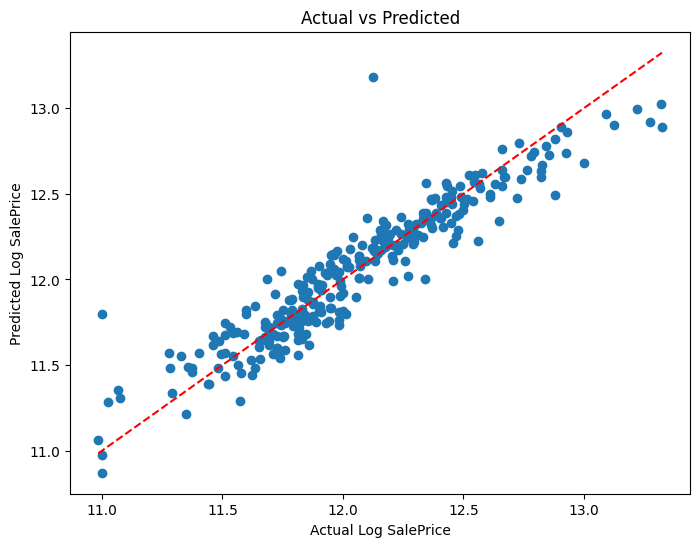

In [20]:
# Scatterplot of Actual Log SalePrice vs Predicted Log SalePrice
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (8,6))

plt.scatter(y_test, y_test_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual Log SalePrice')
plt.ylabel('Predicted Log SalePrice')
plt.title('Actual vs Predicted')

plt.show()

The scatter plot demonstrated a strong agreement between the actual and predicted housing prices. It showed that the ElasticNet model successfully captures the relationship between property characteristics and housing prices, as most predictions were located close to the ideal prediction line(y=x). Although a small number of larger prediction errors remained, the overall pattern suggested good predictive performance and generalisation ability.

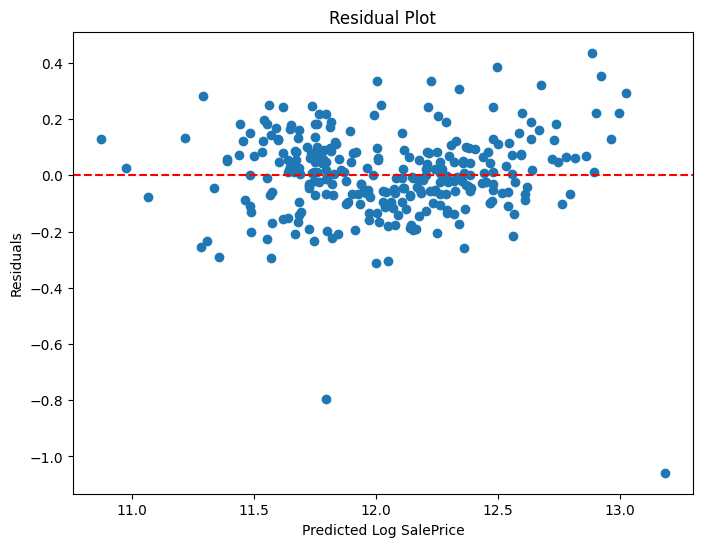

In [24]:
# Residual plot
residuals = y_test - y_test_pred

plt.figure(figsize=(8,6))

plt.scatter(y_test_pred, residuals)

plt.axhline(color = 'r', ls = '--')

plt.xlabel('Predicted Log SalePrice')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

The residuals are generally centred around zero and are distributed without a strong pattern. This suggests that the ElasticNet model captures most of the underlying structure in the data and does not exhibit substantial bias. However, a few large residuals show that some properties are more difficult to predict accurately.

## 4.3 Model Interpretation

In [26]:
# Top 10 Positive Coefficients from ElasticNet Model
coefficient_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_regr.coef_
})

coefficient_df.sort_values(
    by= 'Coefficient',
    ascending = False
).head(10)

,Feature,Coefficient
1,num__Gr Liv Area,0.128420
18,nom__Neighborhood_Crawfor,0.125050
22,nom__Neighborhood_GrnHill,0.120938
0,num__Overall Qual,0.113563
4,num__Total Bsmt SF,0.111418
16,nom__Neighborhood_ClearCr,0.092841
45,nom__MS Zoning_RL,0.080404
30,nom__Neighborhood_NoRidge,0.074454
11,ord__Kitchen Qual,0.067966
37,nom__Neighborhood_StoneBr,0.064624


In [27]:
# Top 10 Negative Coefficients from ElasticNet Model
coefficient_df.sort_values(
    by='Coefficient'
).head(10)

,Feature,Coefficient
40,nom__MS Zoning_A (agr),-0.220345
41,nom__MS Zoning_C (all),-0.130755
14,nom__Neighborhood_BrDale,-0.126190
9,num__has_bsmt,-0.074961
12,nom__Neighborhood_Blmngtn,-0.066931
25,nom__Neighborhood_MeadowV,-0.060058
28,nom__Neighborhood_NPkVill,-0.055268
19,nom__Neighborhood_Edwards,-0.045739
35,nom__Neighborhood_SawyerW,-0.044274
32,nom__Neighborhood_OldTown,-0.039755


In [28]:
# Count Zero Coefficients
np.sum(best_regr.coef_ ==0)

np.int64(8)

In [29]:
# Check Removed Features
coefficient_df[coefficient_df['Coefficient'] == 0]

,Feature,Coefficient
21,nom__Neighborhood_Greens,-0.0
24,nom__Neighborhood_Landmrk,0.0
27,nom__Neighborhood_NAmes,0.0
33,nom__Neighborhood_SWISU,-0.0
36,nom__Neighborhood_Somerst,0.0
43,nom__MS Zoning_I (all),0.0
44,nom__MS Zoning_RH,0.0
46,nom__MS Zoning_RM,0.0


ElasticNet retained many of the influential predictors such as `Gr Liv Area`, `Overall Qual`, `Total Bsmt SF` and several neighbourhood-related variables identified by the Linear Regression model. These features continued to show relatively large coefficient magnitudes which indicate their importance in predicting housing prices.
Unlike Linear Regression, ElasticNet applied regularisation and reduced the coefficients of less informative variables. Eight features were assigned coefficients of zero and they were removed from the model. This demonstrates ElasticNet's ability to perform implicit feature selection while maintaining predictive performance comparable to Linear Regression.

## 4.4 Business Interpretation

- The ElasticNet model achieved very similar predictive performance as the Linear Regression model. This suggests that the selected features contatin substantial predictive information and that regularisation provides only limited additional benefit for the current feature set.
- Key features of housing prices included living area, overall property quality, basement size and neighbourhood characteristics. These findings are consistent with expectations from the EDA.

# **5. Experiment Outcomes**

## 5.1 Key Findings

- While ElasticNet automatically reduced model complexity through coefficient shrinkage and feature selection, it achieved predictive performance comparable to Linear Regression.
- The regularisation process did not lead to a meaningful improvement in predictive accuracy. It suggest that the selected features were already relatively stable.

ElasticNet maintained predictive performance similar to Linear Regression while reducing model complexity through coefficient shrinkage and implicit feature selection.

## 5.2 Hypothesis Evaluation

**The hypothesis was partially supported.** Regularisation controlled model complexity without reducing predictive accuracy as the ElastiNet model achieved predictive performance comparable to the Linear Regression model. However, ElasticNet did not provide a meaningful improvement in prediction performance. It suggests that the selected features were already relatively stable.

## 5.3 Limitations

- Although ElasticNet reduced model complexity by shrinking and removing less informative features, the model remains a linear approach and may not fully capture complex non-linear relationships within the housing market. 
- Only a limited subset of features was included in the modelling process and potentially useful information from excluded variables may have been lost during feature selection. 
- The performance difference between ElasticNet and Linear Regression was minimal. (Regularisation provided limited additional benefit for the current dataset.)

## 5.4 Next Experiment

The next experiment will evaluate a Random Forest Regression model. Unlike Linear Regression and ElasticNet, Random Forest can capture non-linear relationships and interactions between variables. Ths model will be compared against the current ElasticNet and Linear Regression models to determine whether a tree-based approach can improve predictive performance.